In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from mpl_toolkits.mplot3d import Axes3D

In [51]:
data = {

    "Area_sqft": [800, 1100, 1200, 1500, 1800, 2000, 2300],

    "Bedrooms": [1, 3, 2, 3, 3, 4, 4],

    "Price": [2000000, 4500000, 5500000, 6500000, 7000000, 9000000, 11000000]

}


In [52]:
df = pd.DataFrame(data)
df

,Area_sqft,Bedrooms,Price
0,800,1,2000000
1,1100,3,4500000
2,1200,2,5500000
3,1500,3,6500000
4,1800,3,7000000
5,2000,4,9000000
6,2300,4,11000000


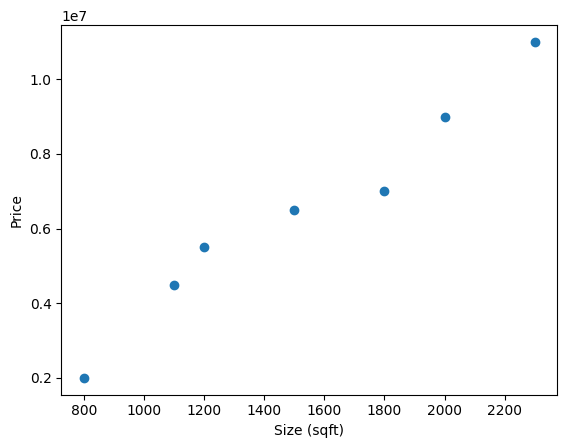

In [53]:
plt.scatter(df["Area_sqft"],df["Price"])

plt.xlabel("Size (sqft)")

plt.ylabel("Price")

plt.show()


In [54]:
#Split features & target

X = df[["Area_sqft", "Bedrooms"]]

y = df["Price"]

#Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


In [55]:
X_scaled

array([[-1.47224319, -1.87638837],
       [-0.8660254 ,  0.14433757],
       [-0.66395281, -0.8660254 ],
       [-0.05773503,  0.14433757],
       [ 0.54848276,  0.14433757],
       [ 0.95262794,  1.15470054],
       [ 1.55884573,  1.15470054]])

In [56]:

X_train, X_test, y_train, y_test = train_test_split( X_scaled, y, test_size=0.2, random_state=42)

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [57]:
X_train

array([[ 0.95262794,  1.15470054],
       [-0.66395281, -0.8660254 ],
       [ 0.54848276,  0.14433757],
       [-0.05773503,  0.14433757],
       [ 1.55884573,  1.15470054]])

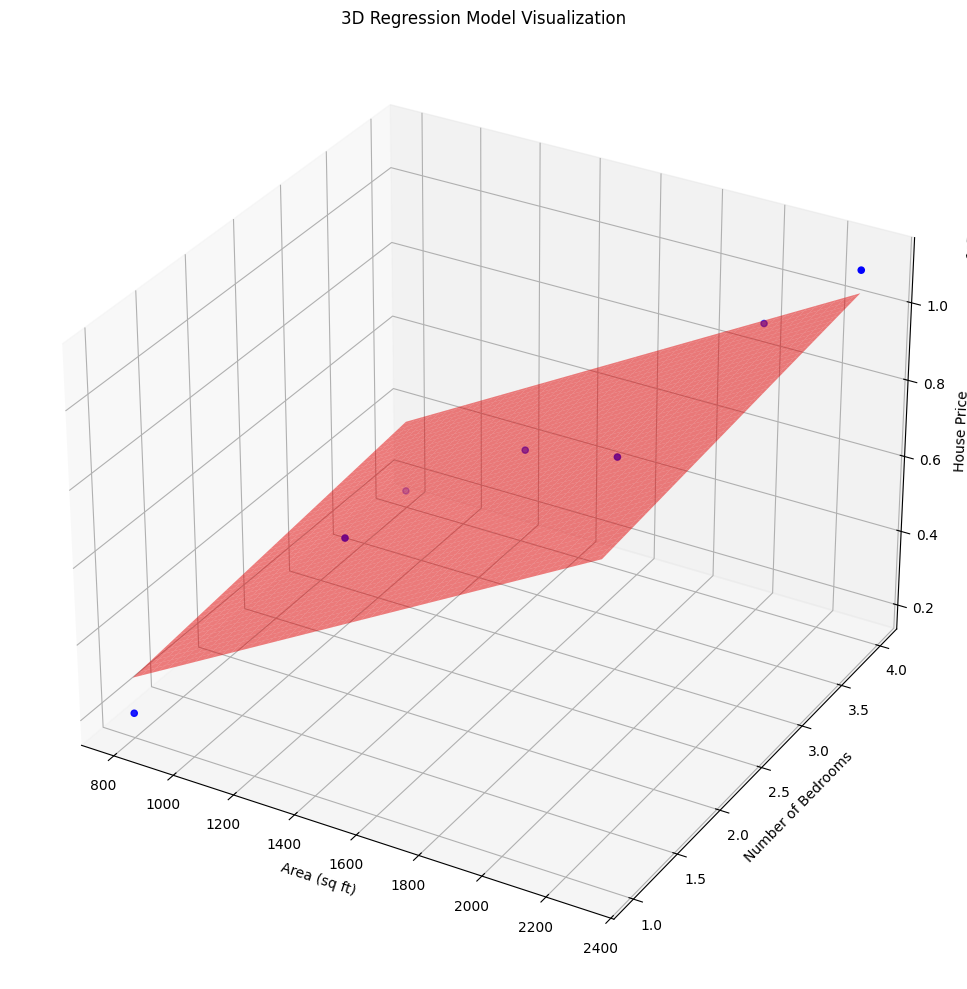

In [72]:
# Prepare data for 3D plot
# Create a meshgrid for the features (Size_sqft and Bedrooms)
X_size_range = np.linspace(X['Area_sqft'].min(), X['Area_sqft'].max(), 100)
X_bedrooms_range = np.linspace(X['Bedrooms'].min(), X['Bedrooms'].max(), 100)
X_size_mesh, X_bedrooms_mesh = np.meshgrid(X_size_range, X_bedrooms_range)

# Combine meshgrid points into an array for scaling and prediction
X_mesh_flat = np.array([X_size_mesh.ravel(), X_bedrooms_mesh.ravel()]).T

# Convert X_mesh_flat to a DataFrame with column names before scaling
X_mesh_flat_df = pd.DataFrame(X_mesh_flat, columns=X.columns)

# Scale the meshgrid points using the same scaler fitted on the training data
X_mesh_scaled = scaler.transform(X_mesh_flat_df)

# Predict prices for the scaled meshgrid points
y_mesh_pred = model.predict(X_mesh_scaled)

# Reshape the predictions back to a grid for plotting the surface
y_mesh_pred = y_mesh_pred.reshape(X_size_mesh.shape)

# Create the 3D plot
#fig = plt.figure(figsize=(10, 8))
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot the actual data points
ax.scatter(df['Area_sqft'], df['Bedrooms'], df['Price'], color='blue', label='Actual Data Points')

# Plot the regression plane
ax.plot_surface(X_size_mesh, X_bedrooms_mesh, y_mesh_pred, alpha=0.5, color='red', label='Regression Plane')

# Set labels and title
ax.set_xlabel('Area (sq ft)')
ax.set_ylabel('Number of Bedrooms')
ax.set_zlabel('House Price')
#ax.set_zlabel("House Price (₹)", labelpad=30)
ax.set_title('3D Regression Model Visualization')

# Add a legend, although plot_surface doesn't directly support labels in legend, it helps conceptually
# For surface legend, a custom approach might be needed, but for now, the title explains.
plt.tight_layout()
plt.show()